In [25]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
# this is used for the Q-Q plot in residual analysis
import scipy.stats as stats

In [26]:
# loading the dataset
df = pd.read_csv("merged ai and job market.csv")

In [27]:
'''Converting experience levels into numerical values so they can be used in a regression model.'''

# simple encoding of experience
experience_map = {"entry": 0, "mid": 1, "senior": 2}

df["experience_encoded"] = df["experience"].map(experience_map)

# delete rows that don't map correctly
df = df.dropna(subset=["experience_encoded"])

In [28]:
# defining features and target
X = df[["experience_encoded"]] # X contains the input feature used to make predictions

y = df["salary_usd"] # y contains the target variable we want to predict

In [29]:
'''Split the dataset into training and testing sets, 80% is used for training and 20% for testing'''

# splitting the data into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [30]:
'''Create and train a linear regression model. This model is supposed to learn the relationship between 
experience level and salary'''

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
'''We use the trained model to predict salaries for the test dataset'''

y_pred = model.predict(X_test)

Evaluating the model

In [ ]:
'''
MAE measures the average prediction error
MSE penalizes larger errors more heavily
RMSE is easier to interpret because it is in the same units as salary
R^2 measures how much variation in salary is explained by the model
'''

In [43]:
# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error
rmse = np.sqrt(mse)

# R^2 Score
r2 = r2_score(y_test, y_pred)

In [44]:
# Print metrics
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R^2 Score:", r2)

Mean Absolute Error (MAE): 22896.29513893301
Mean Squared Error (MSE): 824759320.4570317
Root Mean Squared Error (RMSE): 28718.62323401022
R^2 Score: 0.3876488585272282


In [35]:
# interpreting the model
# The intercept represents the predicted salary for an entry-level position
# The coefficient shows how much salary changes as experience level increases

print("Intercept:", model.intercept_)
print("Coefficient (experience):", model.coef_[0])

Intercept: 89054.86270402068
Coefficient (experience): 27736.913440973407


These results indicate that the model captures some relationship between experience and salary, but the predictions are still fairly limited. An R² score of about 0.39 means that the model explains roughly 39% of the variation in salary. This suggests that experience is an important factor, but salary is also influenced by many additional variables, such as skills, location, job title, and remote work type.

The intercept and coefficient also support this interpretation. The intercept predicts a base salary of about 89,055 for entry-level positions, while the coefficient shows that salary increases by approximately 27,737 for each increase in experience level.

---

In [36]:
# The learning curve helps determine whether the model improves as it sees more training data

In [37]:
# creating a learning curve
train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, cv=5, scoring='r2', train_sizes=np.linspace(0.1, 1.0, 10))

In [38]:
'''
Compute the average training and validation scores across all cross-validation folds.
This gives a more reliable estimate of model performance instead of relying on results from only one split of the data.
'''
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

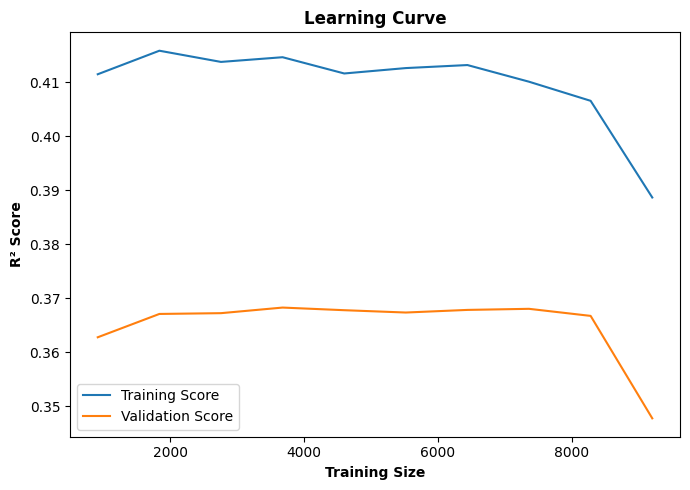

In [39]:
# Plot learning curve
plt.figure(figsize=(7,5))

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")

plt.xlabel("Training Size", fontweight='bold')
plt.ylabel("R² Score", fontweight='bold')
plt.title("Learning Curve", fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

Learning Curve Analysis

The learning curve shows that both the training and validation scores remain relatively low and close together. This indicates that the model is underfitting rather than overfitting.

Although adding more training data slightly improves the model, the performance eventually plateaus. This suggests that the model is too simple to fully capture salary patterns using only experience level.

---

Residual Analysis

In [40]:
# Residuals are the differences between actual salaries and predicted salaries
# Here we plot a histogram of residuals to check whether the errors follow a normal distribution

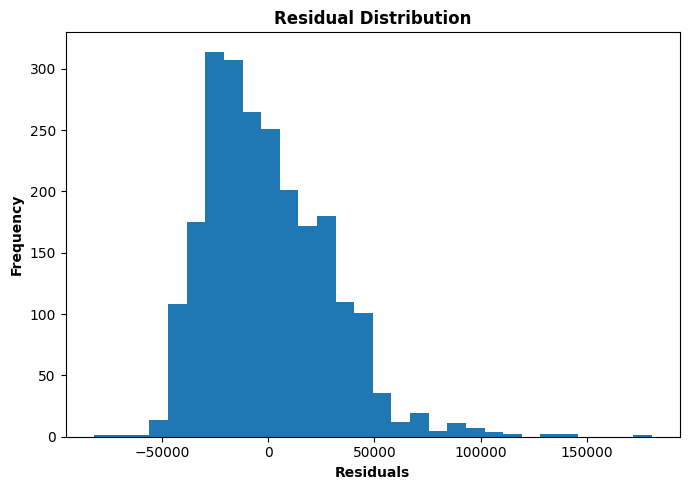

In [41]:
# Residuals = actual - predicted
residuals = y_test - y_pred

# Histogram of residuals
plt.figure(figsize=(7,5))

plt.hist(residuals, bins=30)

plt.xlabel("Residuals", fontweight='bold')
plt.ylabel("Frequency", fontweight='bold')
plt.title("Residual Distribution", fontweight='bold')

plt.tight_layout()
plt.show()

Residual Analysis

The residual histogram on page 4 appears somewhat bell-shaped, which suggests that many prediction errors are distributed around zero. However, the distribution is slightly skewed and contains some larger positive residuals, indicating that the model struggles with certain salary predictions.

---

Q-Q Plot

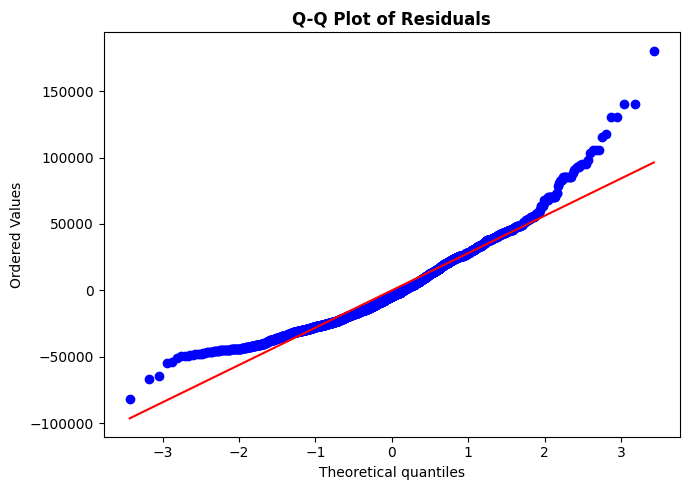

In [42]:
# A Q-Q plot compares the residual distribution to a perfectly normal distribution

plt.figure(figsize=(7,5))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals", fontweight='bold')

plt.tight_layout()
plt.show()

The Q-Q plot shows noticeable deviations from the reference line, especially at the tails. This means the residuals are not perfectly normally distributed.

This suggests that the model does not fully satisfy the assumptions of linear regression and that some salaries may contain outliers or nonlinear patterns that the model cannot capture.